In [71]:
import matplotlib.pyplot as plt
import sqlite3
import numpy as np
import pandas as pd

In [79]:
db_path = r"C:\Users\tmerri03\Desktop\Temp Neural Files\neurons.db"
con = sqlite3.connect(db_path)
cur = con.cursor()

cur.execute('''
            SELECT id, session_id, unit_id, spike_file, unit_loc_x, unit_loc_y, label
            FROM neurons
            WHERE (
                manual_isi_1 < 1
                )
              AND spike_file IS NOT NULL
            ''')
neurons = cur.fetchall()

neurons_df = pd.DataFrame(
    neurons,
    columns=['id', 'session_id', 'unit_id', 'spike_file', 'unit_loc_x', 'unit_loc_y', 'label']
)


In [101]:
session_ids = pd.unique(neurons_df['session_id'])
print(f'There are {len(session_ids)} unique session IDs')
ncm_ids = [id for id in session_ids if 'ncm' in id.lower()]
print(f'There are {len(ncm_ids)} unique NCM IDs')

ncm_df = neurons_df[neurons_df['session_id'].isin(ncm_ids)].reset_index(drop=True)

There are 36 unique session IDs
There are 22 unique NCM IDs


In [102]:
locs = pd.DataFrame(columns=('session_id', 'ml_coord', 'ap_coord', 'dv_coord', 'color'))
for r, row in ncm_df.iterrows():
    for i in row['session_id'].split(' '):
        if 'ap' in i.lower():
            ap = float(i.lower().split('a')[0])
        elif 'ml' in i.lower():
            ml = float(i.lower().split('m')[0])

            if i.lower().split('-')[-1] == 'l':
                ml = -ml
        elif 'um' in i.lower():
            dv = float(i.lower().split('u')[0])
    locs.loc[r, 'session_id'] = row['session_id']
    locs.loc[r, 'unit_id'] = row['unit_id']
    locs.loc[r, 'ml_coord'] = ml - row['unit_loc_x']/1000
    locs.loc[r, 'ap_coord'] = ap
    locs.loc[r, 'dv_coord'] = dv/1000 - row['unit_loc_y']/1000

    if row['label'] == 'auditory':
        locs.loc[r, 'color'] = 'green'
    else:
        locs.loc[r, 'color'] = 'red'


In [103]:
locs['ml_coord'] = pd.to_numeric(locs['ml_coord'], errors='coerce')
locs['ap_coord'] = pd.to_numeric(locs['ap_coord'], errors='coerce')
locs['dv_coord'] = pd.to_numeric(locs['dv_coord'], errors='coerce')
print(locs[['ml_coord', 'ap_coord', 'dv_coord']].dtypes)

ml_coord    float64
ap_coord    float64
dv_coord    float64
dtype: object


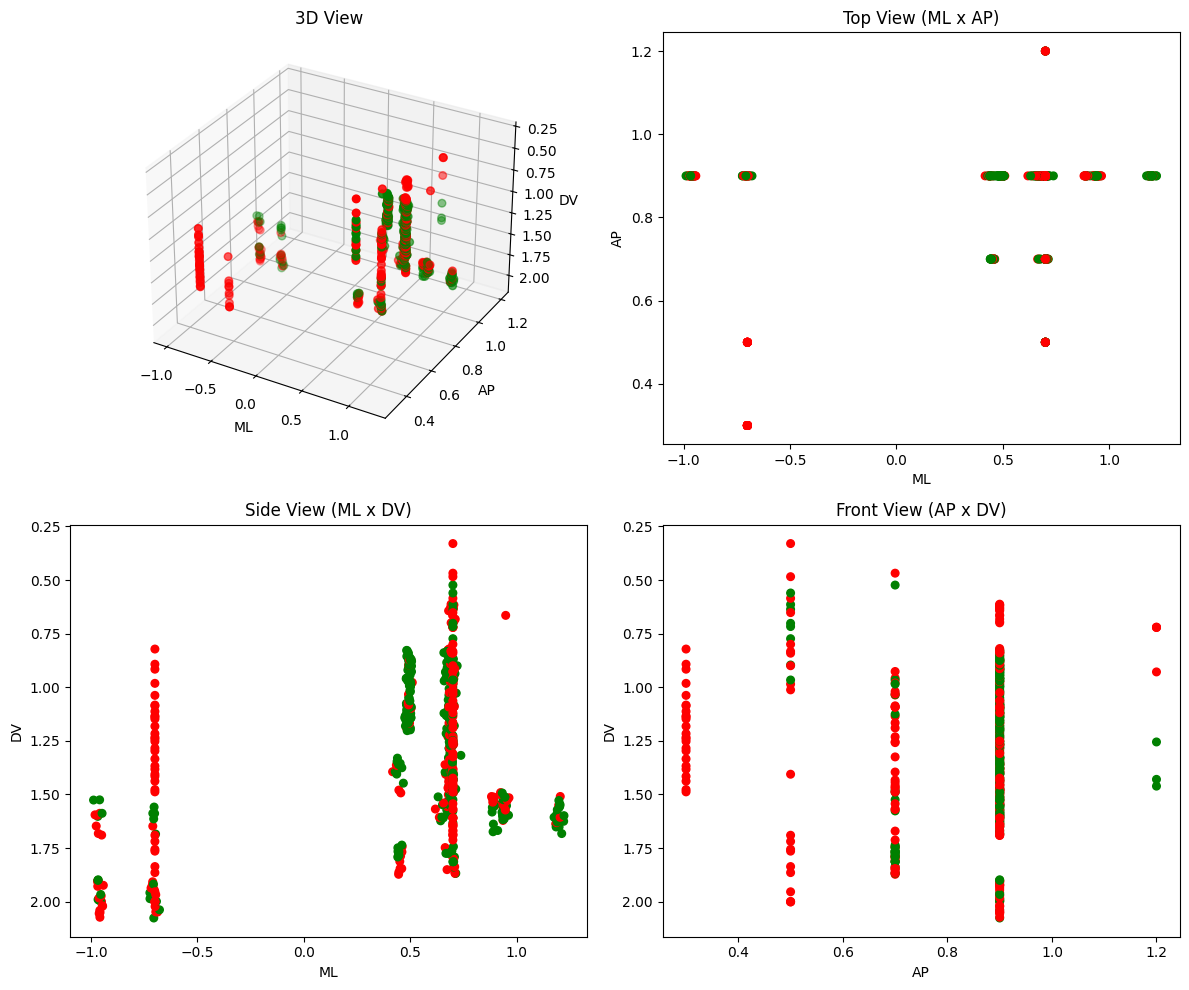

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure coords are numeric
locs['ml_coord'] = pd.to_numeric(locs['ml_coord'], errors='coerce')
locs['ap_coord'] = pd.to_numeric(locs['ap_coord'], errors='coerce')
locs['dv_coord'] = pd.to_numeric(locs['dv_coord'], errors='coerce')
locs = locs.dropna(subset=['ml_coord','ap_coord','dv_coord'])

ml = locs['ml_coord'].values
ap = locs['ap_coord'].values
dv = locs['dv_coord'].values
colors = locs['color'].values

fig = plt.figure(figsize=(12,10))

# ---------------- 3D plot ----------------
ax3d = fig.add_subplot(221, projection='3d')
ax3d.scatter(ml, ap, dv, c=colors, s=30)

ax3d.set_xlabel('ML')
ax3d.set_ylabel('AP')
ax3d.set_zlabel('DV')
ax3d.set_title('3D View')

# ---------------- Top view (ML vs AP) ----------------
ax_top = fig.add_subplot(222)
ax_top.scatter(ml, ap, c=colors, s=30)
ax_top.set_xlabel('ML')
ax_top.set_ylabel('AP')
ax_top.set_title('Top View (ML x AP)')

# ---------------- Side view (ML vs DV) ----------------
ax_side = fig.add_subplot(223)
ax_side.scatter(ml, dv, c=colors, s=30)
ax_side.set_xlabel('ML')
ax_side.set_ylabel('DV')
ax_side.set_title('Side View (ML x DV)')

# ---------------- Front view (AP vs DV) ----------------
ax_front = fig.add_subplot(224)
ax_front.scatter(ap, dv, c=colors, s=30)
ax_front.set_xlabel('AP')
ax_front.set_ylabel('DV')
ax_front.set_title('Front View (AP x DV)')

# Flip DV axis
ax3d.invert_zaxis()
ax_side.invert_yaxis()
ax_front.invert_yaxis()

plt.tight_layout()
plt.show()